# 🧍 Human Body Matting — All-in-One Notebook

**Run every cell top-to-bottom. Everything happens automatically:**
1. Install dependencies
2. Import libraries & define custom loss/metrics
3. Data augmentation pipeline
4. Load dataset
5. Build U-Net model
6. Train with early stopping
7. Plot learning curves
8. Evaluate: background removal & replacement
9. Threshold analysis (Dice vs Threshold curve)
10. Save model
11. **Launch interactive Streamlit app** (accessible in browser via public URL)

---
| Feature | Baseline | This Notebook |
|---|---|---|
| Loss Function | Binary Crossentropy | **Dice + BCE Combined Loss** |
| Metrics | Accuracy + broken IoU | **Accuracy + Fixed IoU + Dice Coefficient** |
| Data Augmentation | None | **Flip, Brightness, Contrast Jitter** |
| Background Handling | Remove only (black) | **Remove + Replace with custom BG** |
| Deployment | Static notebook | **Interactive Streamlit App (live URL)** |
| Threshold | Hardcoded 0.1 | **Scientifically found via Dice curve** |

## Cell 1 — Install Dependencies

> Uses the `ai_app` Python 3.10 conda environment to avoid Python 3.7 incompatibilities.

In [1]:
!/opt/conda/envs/ai_app/bin/python --version


/bin/bash: /opt/conda/envs/ai_app/bin/python: No such file or directory


In [1]:
import subprocess
import sys

def pip_install(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *args])

pip_install('streamlit')
pip_install('pyngrok')
pip_install('opencv-python-headless')
pip_install('pillow')

print('✓ Dependencies ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 21.7 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.6/311.6 kB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 51.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 10.2 MB/s eta 0:00:00
  Created wheel for validators: filename=validators-0.20.0-py3-none-any.whl size=19582 sha256=597a1106d5f86dcfd01f54a8e9ca12871a27672a56e51a41718063d09c36bd6d
  Stored in directory: /root/.cache/pip/wheels/5f/55/ab/36a76989f7f88d9ca7b1f68da6d94252bb6a8d6ad4f18e04e9
Successfully built validators
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.4
    Uninstalling protobuf-3.19.4:
      Successfully uninstalled protobuf-3.19.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-io 0.21.0 requires tensorflow-io-gcs-filesystem==0.21.0, which is not installed.
beatrix-jupyterlab 3.1.7 requires google-cloud-bigquery-storage, which is not installed.
wandb 0.12.21 requires protobuf<4.0dev,>=3.12.0, but you have protobuf 4.24.4 which is incompatible.
tfx-bsl 1.9.0 requires protobuf<3.21,>=3.13, but you have protobuf 4.24.4 which is incompatible.
tfx-bsl 1.9.0 requires tensorflow!=2.0.*,!=2.1.*,!=2.2.*,!=2.3.*,!=2.4.*,!=2.5.*,!=2.6.*,!=2.7.*,!=2.8.*,<3,>=1.15.5, but you have tensorflow 2.6.4 which is incompatible.
tensorflow 2.6.4 requires h5py~=3.1.0, but you have h5py 3.7.0 which is incompatible.
tensorflow 2.6.4 requires numpy~=1.19.2, but you have numpy 1.21.6 which is incompatible.
tensorflow 2.6.4 requires tensorboard<2.7,>=2.6.0, but you have tensorboard 2.10.0 which is incompa

✓ Dependencies ready


## Cell 2 — Imports

**Fix applied:** All `keras` imports replaced with `tf.keras` to avoid backend conflicts between
standalone Keras and TensorFlow 2.6. Using standalone `import keras` alongside `import tensorflow`
causes `AttributeError: module 'keras.optimizers' has no attribute 'Adam'` and related crashes.


In [2]:
# Required for TensorFlow 2.6 compatibility in this environment
# (downgrade protobuf from 4.x to 3.20.x)
!pip install protobuf==3.20.3 -q
print('✓ protobuf pinned for TF 2.6 compatibility')


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-io 0.21.0 requires tensorflow-io-gcs-filesystem==0.21.0, which is not installed.
beatrix-jupyterlab 3.1.7 requires google-cloud-bigquery-storage, which is not installed.
tfx-bsl 1.9.0 requires tensorflow!=2.0.*,!=2.1.*,!=2.2.*,!=2.3.*,!=2.4.*,!=2.5.*,!=2.6.*,!=2.7.*,!=2.8.*,<3,>=1.15.5, but you have tensorflow 2.6.4 which is incompatible.
tensorflow 2.6.4 requires h5py~=3.1.0, but you have h5py 3.7.0 which is incompatible.
tensorflow 2.6.4 requires numpy~=1.19.2, but you have numpy 1.21.6 which is incompatible.
tensorflow 2.6.4 requires tensorboard<2.7,>=2.6.0, but you have tensorboard 2.10.0 which is incompatible.
tensorflow 2.6.4 requires typing-extensions<3.11,>=3.7, but you have typing-extensions 4.3.0 which is incompatible.
tensorflow-transform 1.9.0 requires tensorflow!=2.0.*,!=2.1.*,!=2.2.*,!=2.3

In [3]:
import os, io, threading, textwrap
import numpy as np
import pandas as pd
import cv2 as cv
import tensorflow as tf
from tensorflow import keras                                   # ← FIXED: was 'import keras'
from tensorflow.keras import backend as K                      # ← FIXED: was 'import keras.backend as K'
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import img_to_array, load_img   # ← FIXED
from tensorflow.image import resize
from tensorflow.keras.layers import (                          # ← FIXED
    Layer, Conv2D, Conv2DTranspose, Dropout,
    MaxPool2D, BatchNormalization, Input, concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback  # ← FIXED

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow : 2.6.4
GPU        : True


## Cell 3 — Custom Loss & Metrics

**Fixes applied:**

1. **`dice_bce_loss` rewritten** — the original caused `InvalidArgumentError: required broadcastable shapes`
   because the Dice and BCE terms had different tensor shapes. The fix flattens both `y_true` and `y_pred`
   to 1-D before all operations, making broadcasting impossible.

2. **`FixedMeanIoU` kept for evaluation only** — do NOT include it in `model.compile()` metrics during
   training. The `confusion_matrix` validator inside `MeanIoU` fires before our `>0.5` cast and crashes
   training. We add it back at evaluation time only.


In [4]:
# ── Fixed Dice + BCE Loss ──────────────────────────────────────────────────────
def dice_bce_loss(y_true, y_pred):
    """
    Combined Dice + Binary Crossentropy loss.

    FIX: Both tensors are flattened to 1-D BEFORE any arithmetic.
    This eliminates all 'required broadcastable shapes' errors that occurred
    when y_true and y_pred had different ranks/shapes at intermediate steps.
    """
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    # Dice loss
    intersection = tf.reduce_sum(y_true * y_pred)
    dice_loss = 1.0 - (2.0 * intersection + 1e-7) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-7
    )

    # Binary crossentropy (needs rank ≥ 1 — already satisfied after reshape)
    bce = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(
            tf.reshape(y_true, [-1, 1]),
            tf.reshape(y_pred, [-1, 1])
        )
    )

    return dice_loss + bce


# ── Dice Coefficient metric ────────────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin)

    return (2.0 * intersection + smooth) / (union + smooth)


# ── Fixed IoU — for EVALUATION only, not used in model.compile() ──────────────
class FixedMeanIoU(tf.keras.metrics.MeanIoU):
    """
    Thresholds sigmoid predictions at 0.5 before computing IoU.
    NOTE: Only use this at model.evaluate() time, NOT in model.compile() metrics.
    The MeanIoU confusion_matrix validator crashes training when combined with
    Dice+BCE loss. Add it manually after training completes.
    """
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_binary = tf.cast(y_pred > 0.5, tf.float32)
        return super().update_state(y_true, y_pred_binary, sample_weight)


print('✓ Custom loss and metrics defined')


✓ Custom loss and metrics defined


## Cell 4 — Data Augmentation

The original had **zero augmentation**. We add random horizontal flip, brightness jitter and contrast jitter.

**Key**: spatial transforms must be applied identically to image AND mask to keep them aligned.

In [5]:
def augment(image, mask):
    """
    Spatial transforms → applied to both image and mask.
    Photometric transforms → image only (mask is binary).
    """
    # Spatial
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)

    # Photometric (image only)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask


print('✓ Augmentation function defined')

✓ Augmentation function defined


## Cell 5 — Background Utilities

In [6]:
def remove_background(image, mask, threshold=0.5):
    alpha = (mask > threshold).astype('float32')
    bg = np.zeros_like(image)   # black background
    return image * alpha + bg * (1 - alpha)

def replace_background(image, mask, background, threshold=0.5):
    """
    Alpha compositing: out = fg×α + bg×(1−α)
    image/mask/background are all H×W float [0,1].
    """
    H, W = image.shape[:2]
    bg   = cv.resize(background, (W, H))
    if bg.max() > 1.0:
        bg = bg / 255.0
    alpha      = (mask > threshold).astype('float32')   # H×W×1
    composited = image * alpha + bg * (1.0 - alpha)
    return np.clip(composited, 0.0, 1.0)


print('✓ Background utilities defined')

✓ Background utilities defined


## Cell 6 — Data Loader

In [7]:
def data_loader(image_df, matting_df, IMAGE_SIZE=224, BATCH_SIZE=64,
                channels=[3, 1], augment_data=False):
    idxs     = np.random.permutation(len(image_df))[:BATCH_SIZE]
    images   = np.zeros((BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, channels[0]))
    mattings = np.zeros((BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, channels[1]))
    masks    = np.zeros((BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, channels[1]))

    for i, idx in enumerate(idxs):
        img_path = (root_img  + '/' + image_df['Folder_ID'][idx] + '/' +
                    image_df['Clip_ID'][idx]  + '/' + image_df['Image_ID'][idx])
        mat_path = (root_mask + '/' + matting_df['Folder_ID'][idx] + '/' +
                    matting_df['Matting_ID'][idx] + '/' + matting_df['Image_ID'][idx])

        image   = resize(img_to_array(load_img(img_path))  / 255.,
                         (IMAGE_SIZE, IMAGE_SIZE)).numpy()
        matting = resize(
                        img_to_array(load_img(mat_path, color_mode='grayscale')) / 255.,
                        (IMAGE_SIZE, IMAGE_SIZE)).numpy()
        mask    = (matting > 0).astype('float32')

        if augment_data:
            img_t, mask_t = augment(tf.constant(image),
                                    tf.constant(mask[:, :, :1]))
            image         = img_t.numpy()
            mask[:, :, :1] = mask_t.numpy()

        images[i]   = image
        mattings[i] = matting
        masks[i]    = mask[:, :, :1]

    return images, mattings, masks


print('✓ Data loader defined')

✓ Data loader defined


## Cell 7 — U-Net Architecture

In [8]:
class EncoderLayerBlock(Layer):
    def __init__(self, filters, rate, pooling=True, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.rate    = rate
        self.pooling = pooling
        self.c1   = Conv2D(filters, 3, padding='same', activation='selu',
                           kernel_initializer='he_normal')
        self.bn1  = BatchNormalization()
        self.drop = Dropout(rate)
        self.c2   = Conv2D(filters, 3, padding='same', activation='selu',
                           kernel_initializer='he_normal')
        self.bn2  = BatchNormalization()
        self.pool = MaxPool2D(pool_size=(2, 2))

    def call(self, X, training=False):
        x = self.bn1(self.c1(X), training=training)
        x = self.drop(x, training=training)
        x = self.bn2(self.c2(x), training=training)
        return (self.pool(x), x) if self.pooling else x

    def get_config(self):
        return {**super().get_config(),
                'filters': self.filters, 'rate': self.rate, 'pooling': self.pooling}


class DecoderLayerBlock(Layer):
    def __init__(self, filters, rate, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.rate    = rate
        self.cT      = Conv2DTranspose(filters, 3, strides=2, padding='same')
        self.next    = EncoderLayerBlock(filters, rate, pooling=False)

    def call(self, X, training=False):
        X, skip = X
        return self.next(concatenate([self.cT(X), skip]), training=training)

    def get_config(self):
        return {**super().get_config(),
                'filters': self.filters, 'rate': self.rate}


print('✓ U-Net layer blocks defined')

✓ U-Net layer blocks defined


## Cell 8 — ShowProgress Callback

In [9]:
class ShowProgress(Callback):
    """Visualize predictions after each epoch."""
    def on_epoch_end(self, epoch, logs=None):
        image, _, mask = data_loader(image_df, matting_df, BATCH_SIZE=1,
                                     IMAGE_SIZE=IMAGE_SIZE)
        pred      = self.model.predict(image, verbose=0)[0]
        dice_val  = dice_coefficient(
            tf.constant(mask[0]), tf.constant(pred)).numpy()
        removed   = remove_background(image[0], pred, threshold=0.3)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(
            f'Epoch {epoch+1}  |  val_loss: {logs["val_loss"]:.4f}  |  Dice: {dice_val:.4f}',
            fontweight='bold')
        axes[0].imshow(image[0]);               axes[0].set_title('Input');         axes[0].axis('off')
        axes[1].imshow((pred[:,:,0] > 0.5), cmap='gray'); axes[1].set_title('Pred Mask');  axes[1].axis('off')
        axes[2].imshow(mask[0][:,:,0], cmap='gray'); axes[2].set_title('GT Mask'); axes[2].axis('off')
        axes[3].imshow(removed[:,:,:3]);        axes[3].set_title('BG Removed');   axes[3].axis('off')
        plt.tight_layout(); plt.show()

## Cell 9 — Load Dataset

In [10]:
root_img  = '../input/aisegmentcom-matting-human-datasets/clip_img'
root_mask = '../input/aisegmentcom-matting-human-datasets/matting'

image_folders   = sorted(os.listdir(root_img))
matting_folders = sorted(os.listdir(root_mask))

image_df   = pd.DataFrame(columns=['Folder_ID', 'Clip_ID',    'Image_ID'],   index=range(34427))
matting_df = pd.DataFrame(columns=['Folder_ID', 'Matting_ID', 'Image_ID'],   index=range(34427))

clip_image_dirs   = [sorted(os.listdir(root_img  + '/' + f)) for f in image_folders]
clip_matting_dirs = [sorted(os.listdir(root_mask + '/' + f)) for f in matting_folders]

k = 0
for i, folder in enumerate(image_folders):
    for clip in clip_image_dirs[i]:
        for image_id in os.listdir(root_img + '/' + folder + '/' + clip):
            image_df.loc[k]   = [folder, clip, image_id]
            matting_id        = clip.split('_')[-1]
            img_stem          = image_id.split('.')[0]
            matting_df.loc[k] = [folder, 'matting_' + matting_id, img_stem + '.png']
            k += 1

print(f'Dataset loaded: {k} image pairs')
image_df.head()

Dataset loaded: 34427 image pairs


,Folder_ID,Clip_ID,Image_ID
0,1803151818,clip_00000000,1803151818-00000062.jpg
1,1803151818,clip_00000000,1803151818-00000465.jpg
2,1803151818,clip_00000000,1803151818-00000314.jpg
3,1803151818,clip_00000000,1803151818-00000681.jpg
4,1803151818,clip_00000000,1803151818-00000594.jpg


## Cell 10 — Load Training Data & Build Model

**Fixes applied:**

1. **`model.compile()` metrics** — `FixedMeanIoU` removed from training metrics (causes crash).
   Only `accuracy` and `dice_coefficient` are used during training. IoU is evaluated separately
   after training completes.

2. **GPU device guard** — falls back to CPU gracefully if no GPU is available, instead of crashing.


In [11]:
IMAGE_SIZE = 224

print('Loading training data (with augmentation)...')
X_train, _, y_train = data_loader(image_df, matting_df, IMAGE_SIZE, 1000,
                                   augment_data=True)
print('Loading validation data...')
X_valid, _, y_valid = data_loader(image_df, matting_df, IMAGE_SIZE, 500)

# Ensure correct shape and dtype — (N, H, W, 1), float32, range [0, 1]
y_train = y_train.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1).astype(np.float32)
y_valid = y_valid.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1).astype(np.float32)

print(f'Train: {X_train.shape}  |  Val: {X_valid.shape}')
print(f'Mask train: {y_train.shape}  dtype={y_train.dtype}  range=[{y_train.min():.2f}, {y_train.max():.2f}]')

# ── Safe device selection ──────────────────────────────────────────────────────
device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f'Using device: {device}')

# ── Build U-Net ────────────────────────────────────────────────────────────────
with tf.device(device):
    inp = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

    p1, c1 = EncoderLayerBlock(16,  0.1)(inp)
    p2, c2 = EncoderLayerBlock(32,  0.1)(p1)
    p3, c3 = EncoderLayerBlock(32,  0.1)(p2)
    p4, c4 = EncoderLayerBlock(64,  0.1)(p3)
    c5     = EncoderLayerBlock(128, 0.2, pooling=False)(p4)

    d1 = DecoderLayerBlock(64,  0.1)([c5, c4])
    d2 = DecoderLayerBlock(32,  0.1)([d1, c3])
    d3 = DecoderLayerBlock(32,  0.1)([d2, c2])
    d4 = DecoderLayerBlock(16,  0.1)([d3, c1])

    output = Conv2D(1, 1, padding='same', activation='sigmoid')(d4)
    model  = keras.models.Model(inputs=inp, outputs=output)

    model.compile(
        loss=dice_bce_loss,
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=[
            'accuracy',
            dice_coefficient,
            # FixedMeanIoU intentionally excluded from training — use at eval time only
        ]
    )

model.summary()


Loading training data (with augmentation)...
Loading validation data...
Train: (1000, 224, 224, 3)  |  Val: (500, 224, 224, 3)
Mask train: (1000, 224, 224, 1)  dtype=float32  range=[0.00, 1.00]
Using device: /GPU:0
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
encoder_layer_block (EncoderLay ((None, 112, 112, 16 2896        input_1[0][0]                    
__________________________________________________________________________________________________
encoder_layer_block_1 (EncoderL ((None, 56, 56, 32), 14144       encoder_layer_block[0][0]        
_____________________________________________________________________________

## Cell 11 — Train

Debug shape-check cells removed (shapes are now validated in Cell 10).


Epoch 1/100
63/63 [==============================] - 27s 188ms/step - loss: 0.6492 - accuracy: 0.8151 - dice_coefficient: 0.8344 - val_loss: 1.9559 - val_accuracy: 0.8141 - val_dice_coefficient: 0.8529

Epoch 00001: val_loss improved from inf to 1.95585, saving model to UNet-Matting-Improved.h5


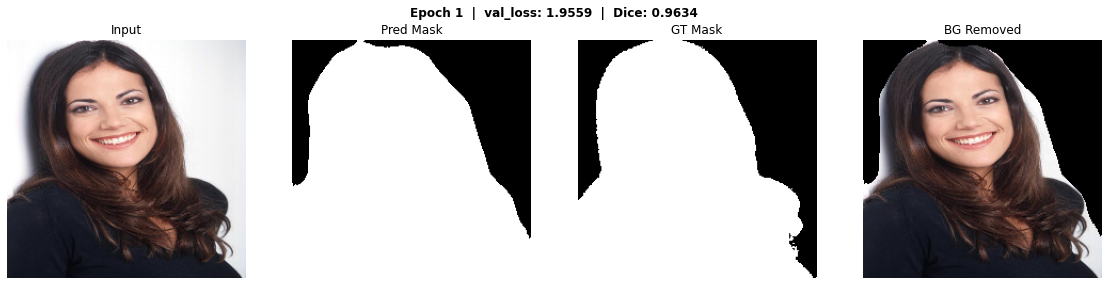

Epoch 2/100
63/63 [==============================] - 9s 146ms/step - loss: 0.3947 - accuracy: 0.8975 - dice_coefficient: 0.9101 - val_loss: 1.0741 - val_accuracy: 0.8538 - val_dice_coefficient: 0.8753

Epoch 00002: val_loss improved from 1.95585 to 1.07413, saving model to UNet-Matting-Improved.h5


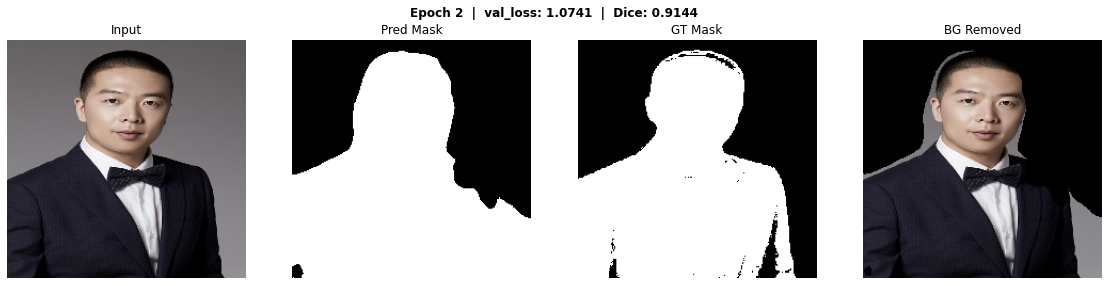

Epoch 3/100
63/63 [==============================] - 9s 149ms/step - loss: 0.3408 - accuracy: 0.9122 - dice_coefficient: 0.9224 - val_loss: 0.5371 - val_accuracy: 0.8990 - val_dice_coefficient: 0.9096

Epoch 00003: val_loss improved from 1.07413 to 0.53715, saving model to UNet-Matting-Improved.h5


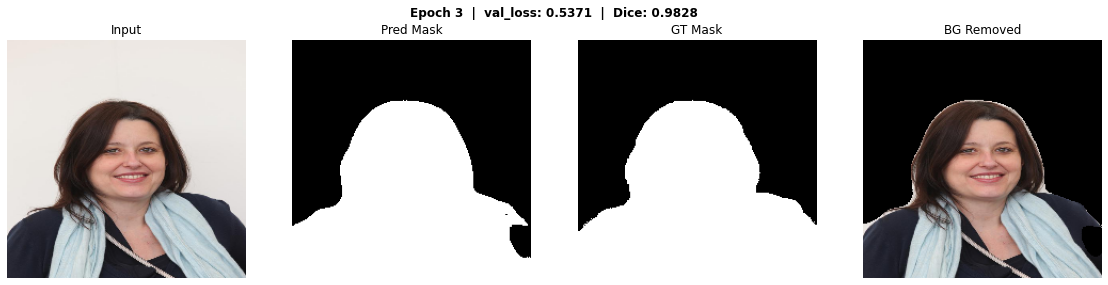

Epoch 4/100
63/63 [==============================] - 10s 152ms/step - loss: 0.2880 - accuracy: 0.9271 - dice_coefficient: 0.9358 - val_loss: 0.4507 - val_accuracy: 0.9076 - val_dice_coefficient: 0.9162

Epoch 00004: val_loss improved from 0.53715 to 0.45068, saving model to UNet-Matting-Improved.h5


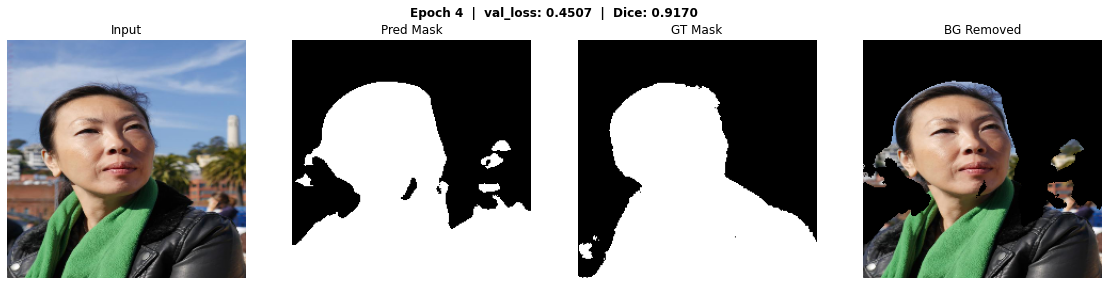

Epoch 5/100
63/63 [==============================] - 10s 155ms/step - loss: 0.2654 - accuracy: 0.9333 - dice_coefficient: 0.9412 - val_loss: 0.4395 - val_accuracy: 0.9136 - val_dice_coefficient: 0.9213

Epoch 00005: val_loss improved from 0.45068 to 0.43952, saving model to UNet-Matting-Improved.h5


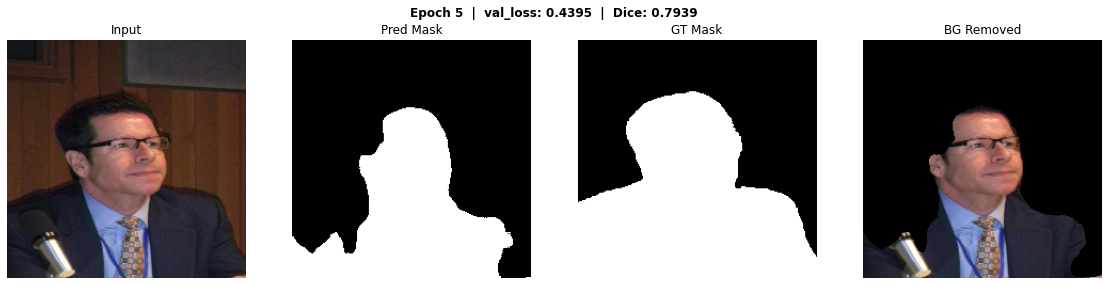

Epoch 6/100
63/63 [==============================] - 10s 157ms/step - loss: 0.2386 - accuracy: 0.9411 - dice_coefficient: 0.9481 - val_loss: 0.3284 - val_accuracy: 0.9264 - val_dice_coefficient: 0.9333

Epoch 00006: val_loss improved from 0.43952 to 0.32842, saving model to UNet-Matting-Improved.h5


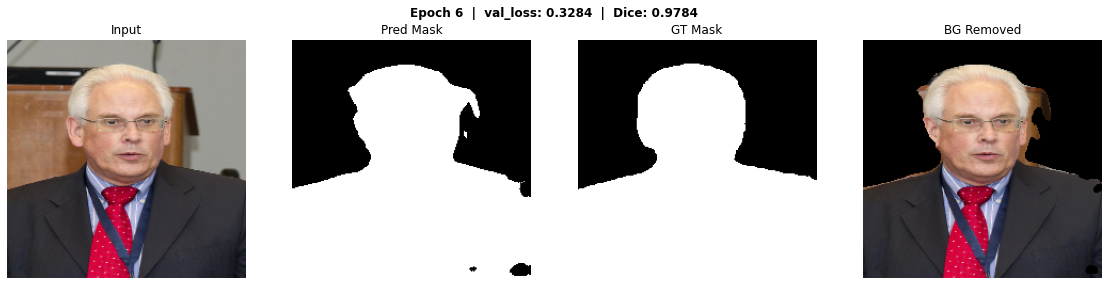

Epoch 7/100
63/63 [==============================] - 10s 161ms/step - loss: 0.2191 - accuracy: 0.9471 - dice_coefficient: 0.9532 - val_loss: 0.3211 - val_accuracy: 0.9271 - val_dice_coefficient: 0.9339

Epoch 00007: val_loss improved from 0.32842 to 0.32109, saving model to UNet-Matting-Improved.h5


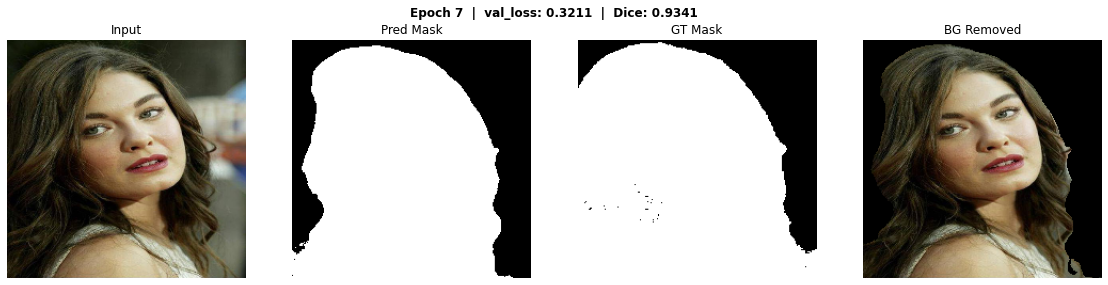

Epoch 8/100
63/63 [==============================] - 11s 168ms/step - loss: 0.2110 - accuracy: 0.9487 - dice_coefficient: 0.9546 - val_loss: 0.2392 - val_accuracy: 0.9429 - val_dice_coefficient: 0.9494

Epoch 00008: val_loss improved from 0.32109 to 0.23917, saving model to UNet-Matting-Improved.h5


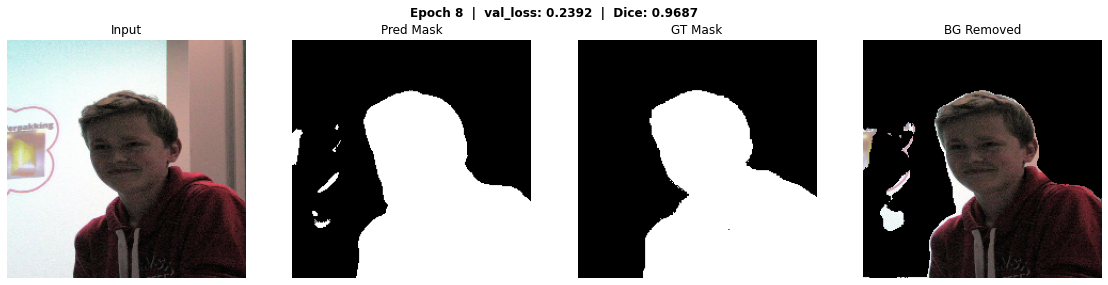

Epoch 9/100
63/63 [==============================] - 11s 174ms/step - loss: 0.1984 - accuracy: 0.9523 - dice_coefficient: 0.9576 - val_loss: 0.2606 - val_accuracy: 0.9382 - val_dice_coefficient: 0.9440

Epoch 00009: val_loss did not improve from 0.23917


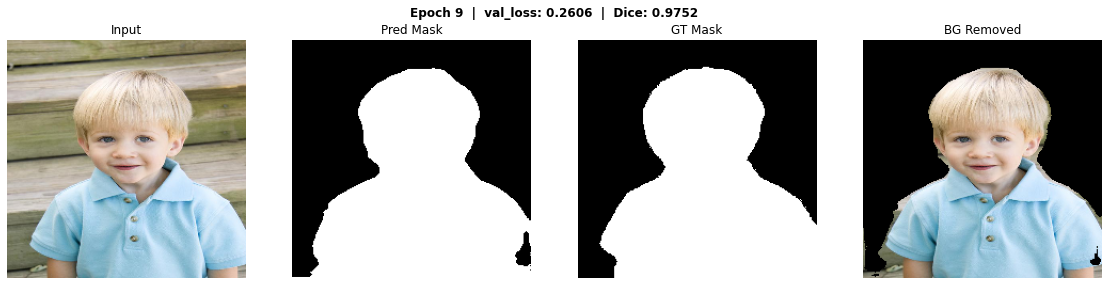

Epoch 10/100
63/63 [==============================] - 11s 174ms/step - loss: 0.1907 - accuracy: 0.9545 - dice_coefficient: 0.9597 - val_loss: 0.2064 - val_accuracy: 0.9516 - val_dice_coefficient: 0.9569

Epoch 00010: val_loss improved from 0.23917 to 0.20636, saving model to UNet-Matting-Improved.h5


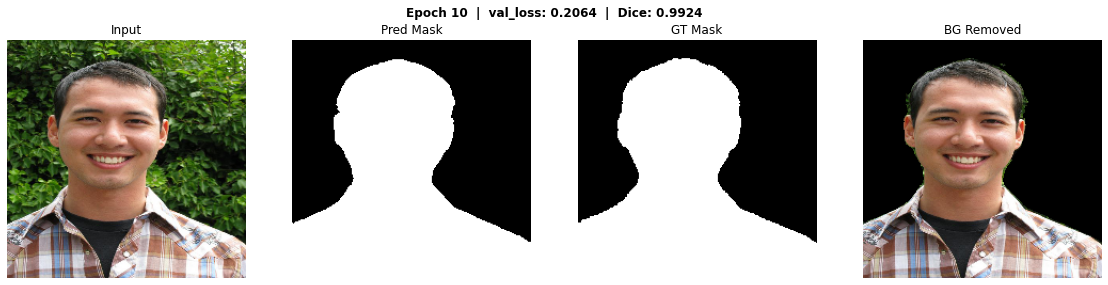

Epoch 11/100
63/63 [==============================] - 11s 167ms/step - loss: 0.1794 - accuracy: 0.9575 - dice_coefficient: 0.9625 - val_loss: 0.2059 - val_accuracy: 0.9531 - val_dice_coefficient: 0.9584

Epoch 00011: val_loss improved from 0.20636 to 0.20588, saving model to UNet-Matting-Improved.h5


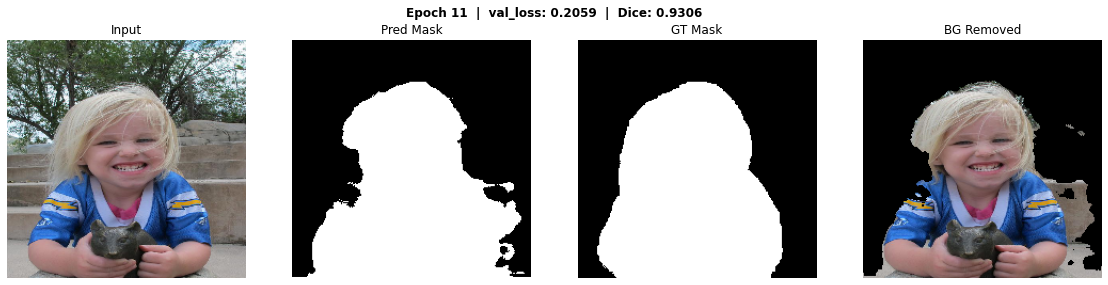

Epoch 12/100
63/63 [==============================] - 10s 164ms/step - loss: 0.1623 - accuracy: 0.9619 - dice_coefficient: 0.9663 - val_loss: 0.2113 - val_accuracy: 0.9539 - val_dice_coefficient: 0.9589

Epoch 00012: val_loss did not improve from 0.20588


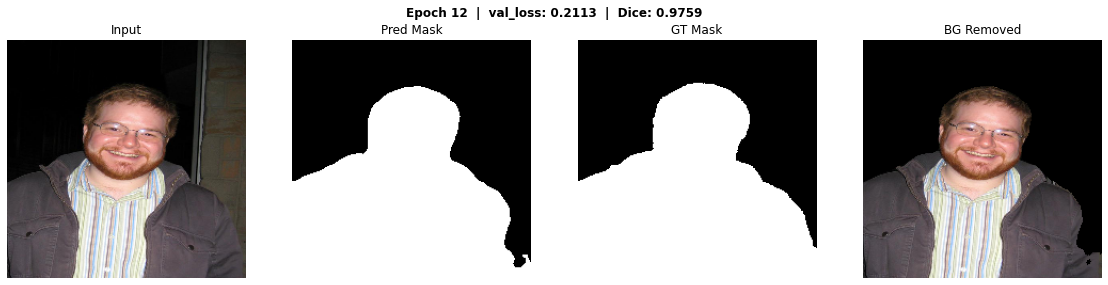

Epoch 13/100
63/63 [==============================] - 10s 164ms/step - loss: 0.1682 - accuracy: 0.9604 - dice_coefficient: 0.9650 - val_loss: 0.2012 - val_accuracy: 0.9541 - val_dice_coefficient: 0.9592

Epoch 00013: val_loss improved from 0.20588 to 0.20118, saving model to UNet-Matting-Improved.h5


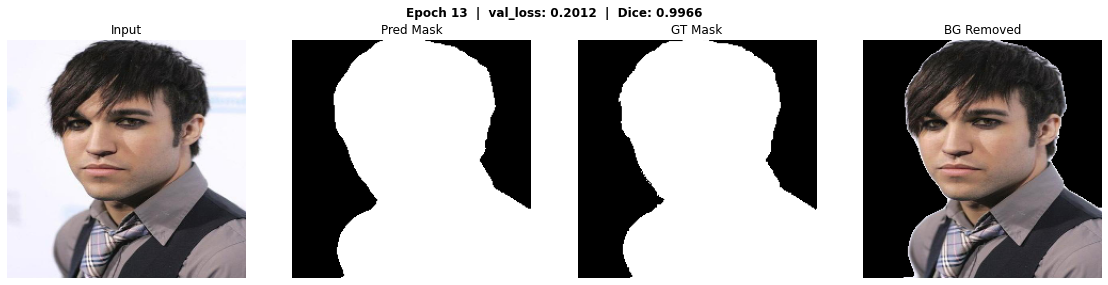

Epoch 14/100
63/63 [==============================] - 10s 165ms/step - loss: 0.1515 - accuracy: 0.9648 - dice_coefficient: 0.9688 - val_loss: 0.1905 - val_accuracy: 0.9553 - val_dice_coefficient: 0.9604

Epoch 00014: val_loss improved from 0.20118 to 0.19049, saving model to UNet-Matting-Improved.h5


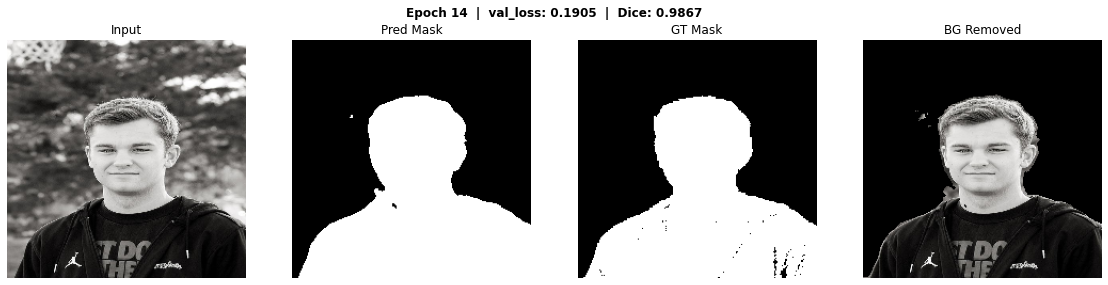

Epoch 15/100
63/63 [==============================] - 10s 167ms/step - loss: 0.1486 - accuracy: 0.9653 - dice_coefficient: 0.9692 - val_loss: 0.2116 - val_accuracy: 0.9518 - val_dice_coefficient: 0.9572

Epoch 00015: val_loss did not improve from 0.19049


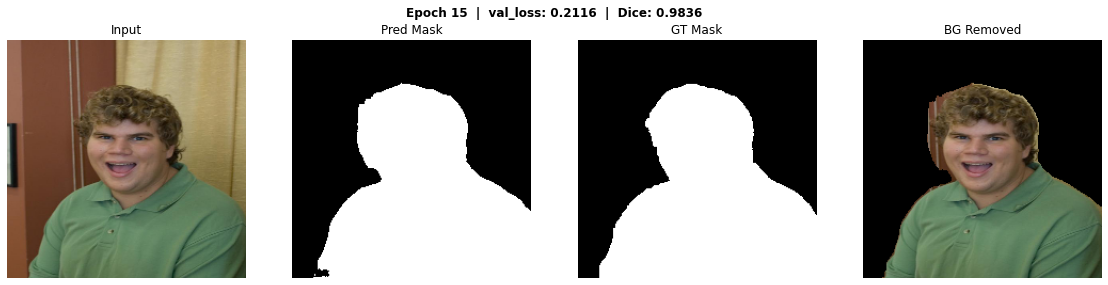

Epoch 16/100
63/63 [==============================] - 11s 168ms/step - loss: 0.1392 - accuracy: 0.9677 - dice_coefficient: 0.9713 - val_loss: 0.1968 - val_accuracy: 0.9545 - val_dice_coefficient: 0.9600

Epoch 00016: val_loss did not improve from 0.19049


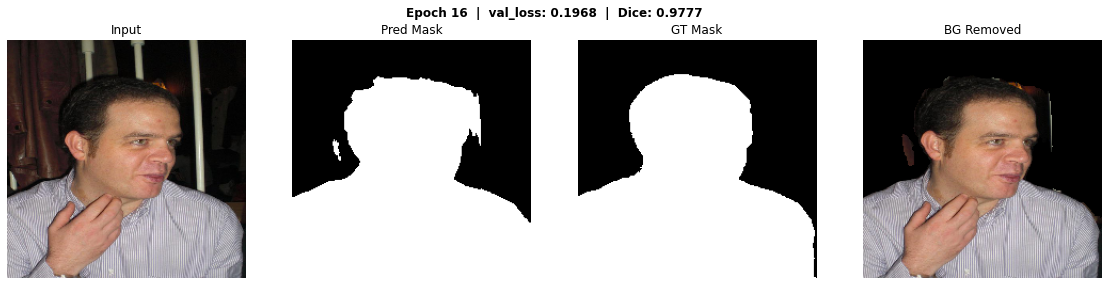

Epoch 17/100
63/63 [==============================] - 11s 169ms/step - loss: 0.1394 - accuracy: 0.9674 - dice_coefficient: 0.9711 - val_loss: 0.1868 - val_accuracy: 0.9581 - val_dice_coefficient: 0.9624

Epoch 00017: val_loss improved from 0.19049 to 0.18682, saving model to UNet-Matting-Improved.h5


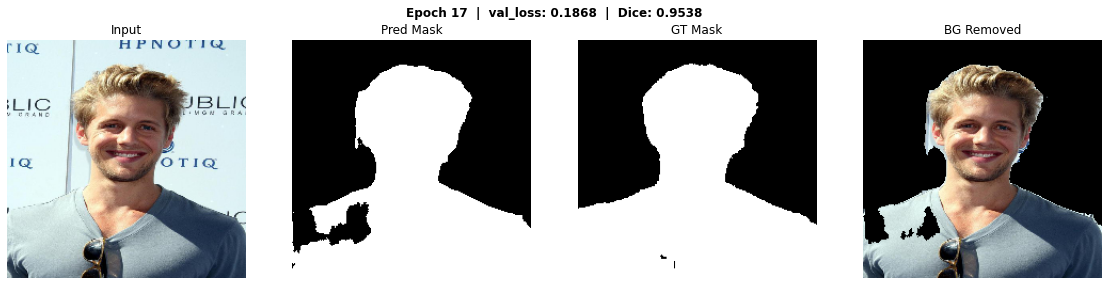

Epoch 18/100
63/63 [==============================] - 11s 168ms/step - loss: 0.1274 - accuracy: 0.9709 - dice_coefficient: 0.9744 - val_loss: 0.1970 - val_accuracy: 0.9553 - val_dice_coefficient: 0.9598

Epoch 00018: val_loss did not improve from 0.18682


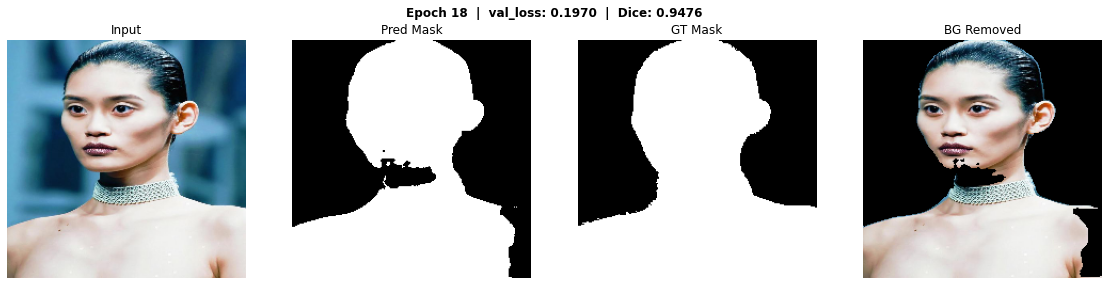

Epoch 19/100
63/63 [==============================] - 11s 167ms/step - loss: 0.1292 - accuracy: 0.9702 - dice_coefficient: 0.9736 - val_loss: 0.2112 - val_accuracy: 0.9509 - val_dice_coefficient: 0.9552

Epoch 00019: val_loss did not improve from 0.18682


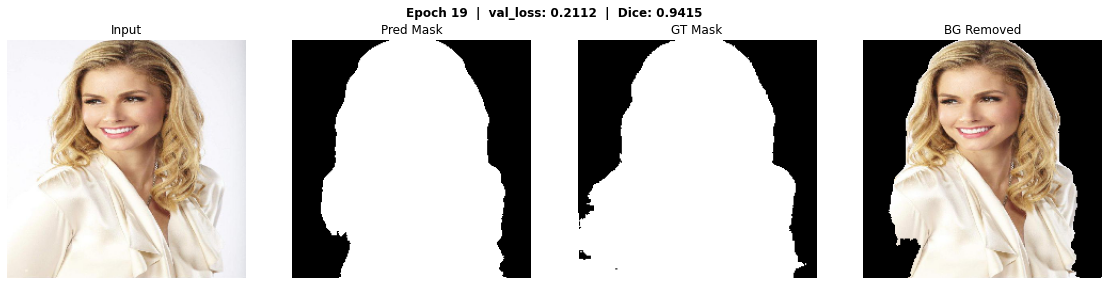

Epoch 20/100
63/63 [==============================] - 10s 167ms/step - loss: 0.1239 - accuracy: 0.9719 - dice_coefficient: 0.9751 - val_loss: 0.2547 - val_accuracy: 0.9443 - val_dice_coefficient: 0.9503

Epoch 00020: val_loss did not improve from 0.18682


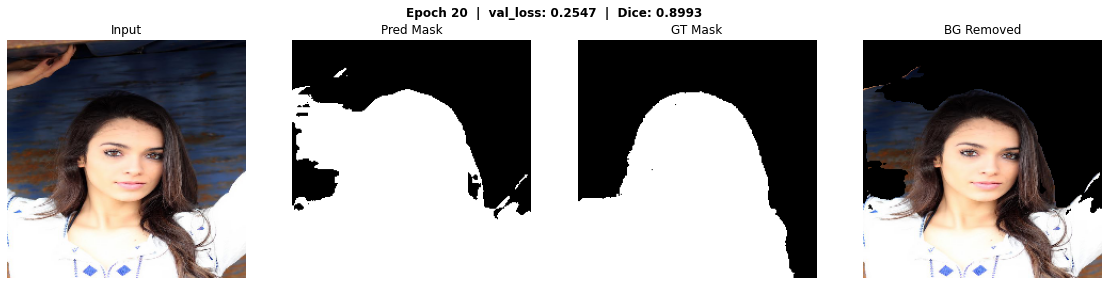

Epoch 21/100
63/63 [==============================] - 10s 166ms/step - loss: 0.1438 - accuracy: 0.9661 - dice_coefficient: 0.9700 - val_loss: 0.1996 - val_accuracy: 0.9578 - val_dice_coefficient: 0.9626

Epoch 00021: val_loss did not improve from 0.18682


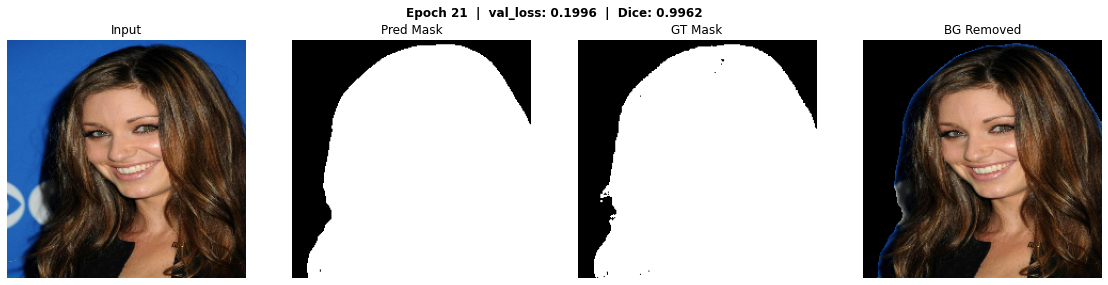

Epoch 22/100
63/63 [==============================] - 10s 166ms/step - loss: 0.1229 - accuracy: 0.9715 - dice_coefficient: 0.9748 - val_loss: 0.1731 - val_accuracy: 0.9609 - val_dice_coefficient: 0.9650

Epoch 00022: val_loss improved from 0.18682 to 0.17309, saving model to UNet-Matting-Improved.h5


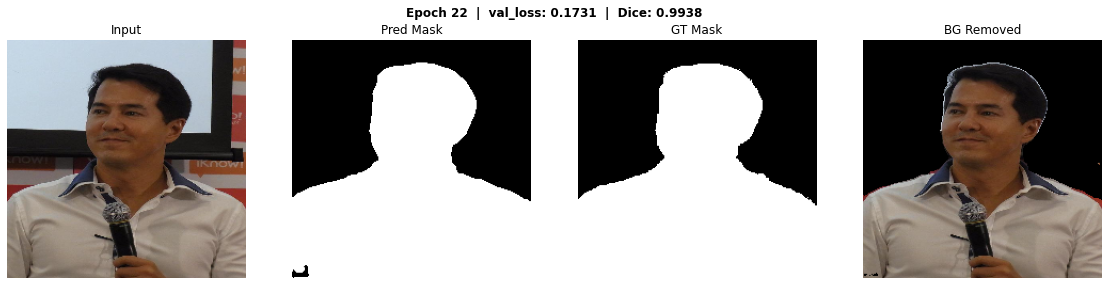

Epoch 23/100
63/63 [==============================] - 10s 166ms/step - loss: 0.1180 - accuracy: 0.9730 - dice_coefficient: 0.9759 - val_loss: 0.1987 - val_accuracy: 0.9573 - val_dice_coefficient: 0.9613

Epoch 00023: val_loss did not improve from 0.17309


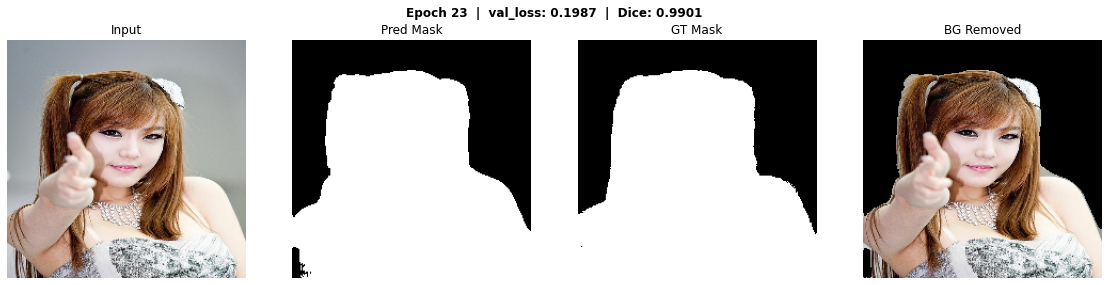

Epoch 24/100
63/63 [==============================] - 10s 166ms/step - loss: 0.1162 - accuracy: 0.9733 - dice_coefficient: 0.9764 - val_loss: 0.1814 - val_accuracy: 0.9611 - val_dice_coefficient: 0.9651

Epoch 00024: val_loss did not improve from 0.17309


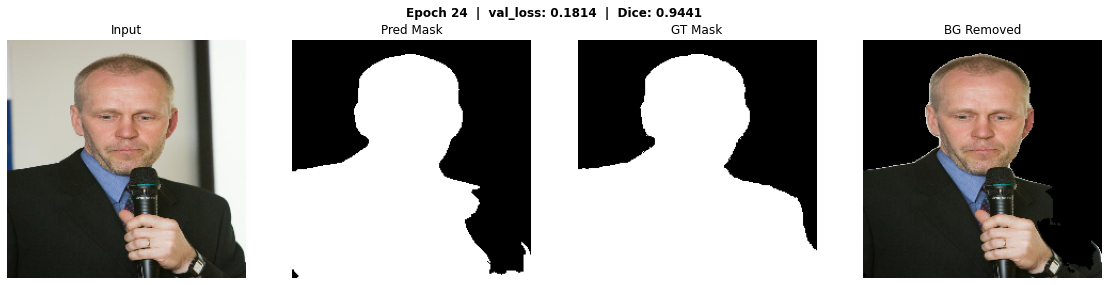

Epoch 25/100
63/63 [==============================] - 10s 167ms/step - loss: 0.1157 - accuracy: 0.9733 - dice_coefficient: 0.9764 - val_loss: 0.1886 - val_accuracy: 0.9578 - val_dice_coefficient: 0.9625

Epoch 00025: val_loss did not improve from 0.17309


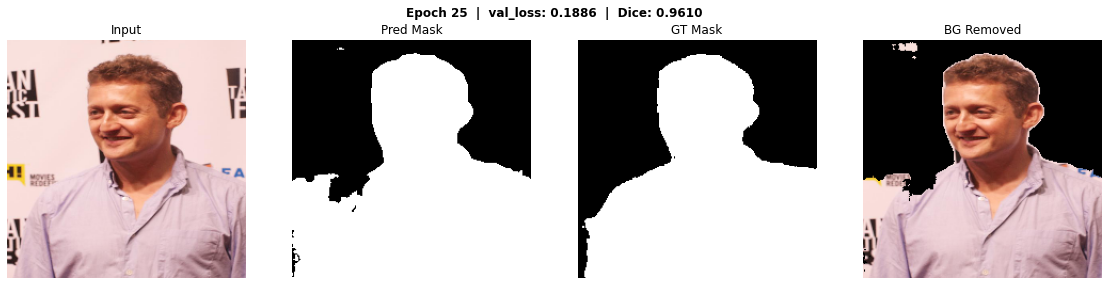

Epoch 26/100
63/63 [==============================] - 10s 167ms/step - loss: 0.1099 - accuracy: 0.9749 - dice_coefficient: 0.9777 - val_loss: 0.1754 - val_accuracy: 0.9598 - val_dice_coefficient: 0.9637

Epoch 00026: val_loss did not improve from 0.17309


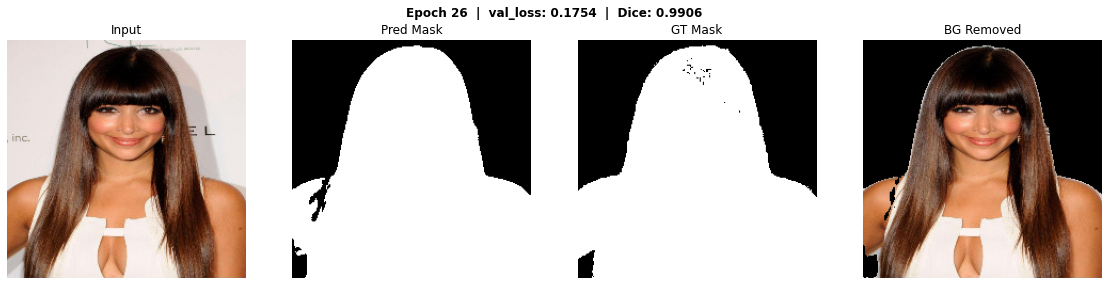

Epoch 27/100
63/63 [==============================] - 10s 167ms/step - loss: 0.0993 - accuracy: 0.9773 - dice_coefficient: 0.9800 - val_loss: 0.1767 - val_accuracy: 0.9623 - val_dice_coefficient: 0.9661

Epoch 00027: val_loss did not improve from 0.17309


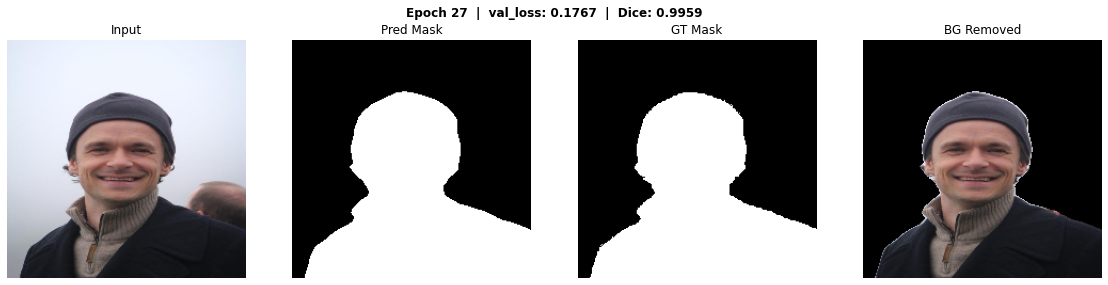

Epoch 28/100
63/63 [==============================] - 11s 168ms/step - loss: 0.0980 - accuracy: 0.9782 - dice_coefficient: 0.9807 - val_loss: 0.1622 - val_accuracy: 0.9649 - val_dice_coefficient: 0.9688

Epoch 00028: val_loss improved from 0.17309 to 0.16216, saving model to UNet-Matting-Improved.h5


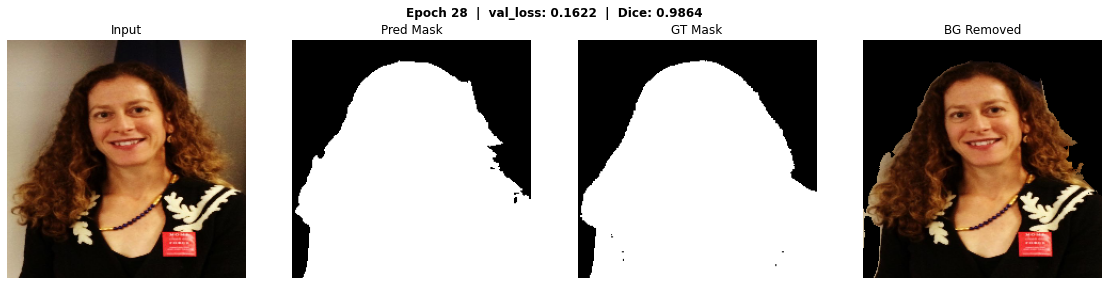

Epoch 29/100
63/63 [==============================] - 11s 168ms/step - loss: 0.1000 - accuracy: 0.9770 - dice_coefficient: 0.9796 - val_loss: 0.1838 - val_accuracy: 0.9582 - val_dice_coefficient: 0.9621

Epoch 00029: val_loss did not improve from 0.16216


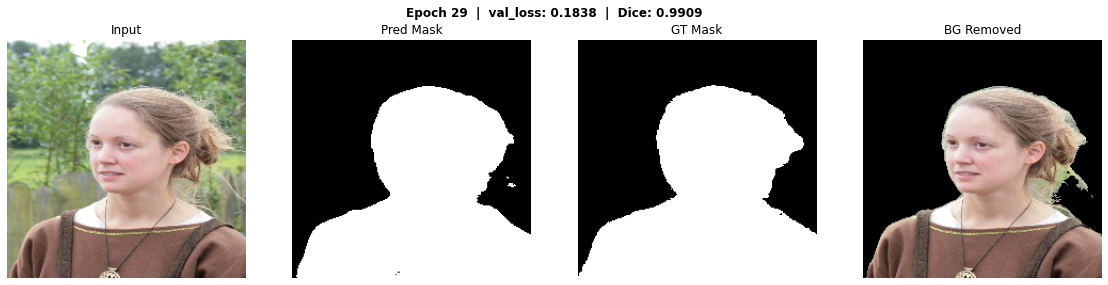

Epoch 30/100
63/63 [==============================] - 11s 168ms/step - loss: 0.0983 - accuracy: 0.9775 - dice_coefficient: 0.9801 - val_loss: 0.1912 - val_accuracy: 0.9616 - val_dice_coefficient: 0.9656

Epoch 00030: val_loss did not improve from 0.16216


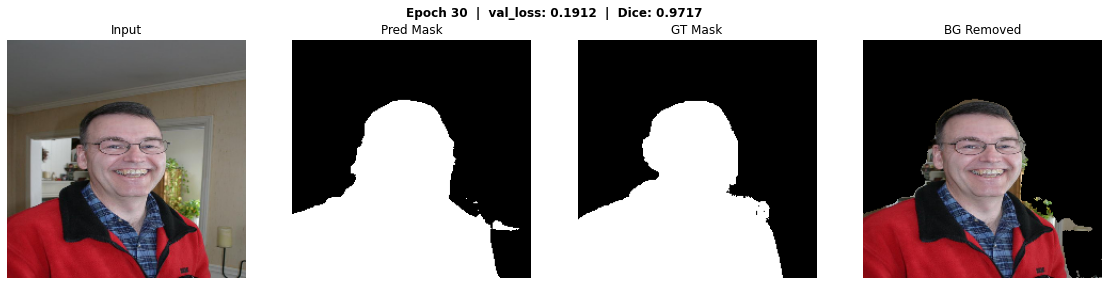

Epoch 31/100
63/63 [==============================] - 11s 168ms/step - loss: 0.0989 - accuracy: 0.9774 - dice_coefficient: 0.9801 - val_loss: 0.1810 - val_accuracy: 0.9593 - val_dice_coefficient: 0.9639

Epoch 00031: val_loss did not improve from 0.16216


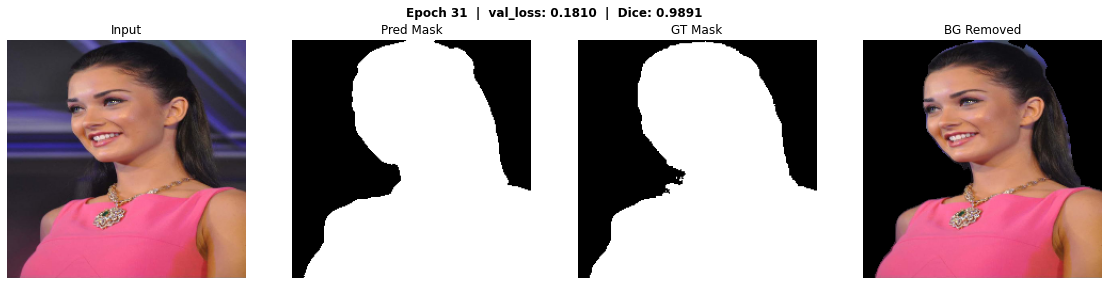

Epoch 32/100
63/63 [==============================] - 11s 168ms/step - loss: 0.0957 - accuracy: 0.9780 - dice_coefficient: 0.9804 - val_loss: 0.1890 - val_accuracy: 0.9621 - val_dice_coefficient: 0.9659

Epoch 00032: val_loss did not improve from 0.16216


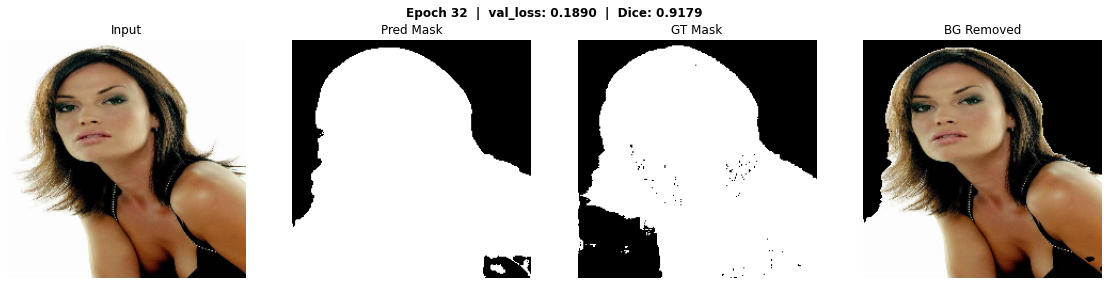

Epoch 33/100
63/63 [==============================] - 11s 169ms/step - loss: 0.0891 - accuracy: 0.9797 - dice_coefficient: 0.9821 - val_loss: 0.1769 - val_accuracy: 0.9646 - val_dice_coefficient: 0.9687

Epoch 00033: val_loss did not improve from 0.16216


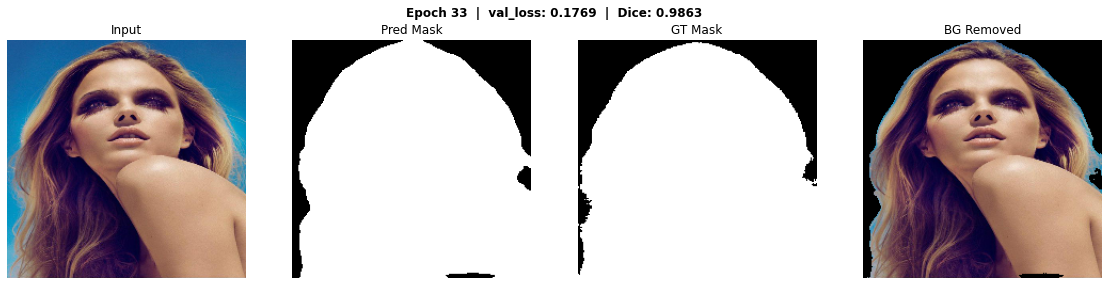

Epoch 34/100
63/63 [==============================] - 11s 168ms/step - loss: 0.0845 - accuracy: 0.9806 - dice_coefficient: 0.9827 - val_loss: 0.1644 - val_accuracy: 0.9637 - val_dice_coefficient: 0.9674

Epoch 00034: val_loss did not improve from 0.16216


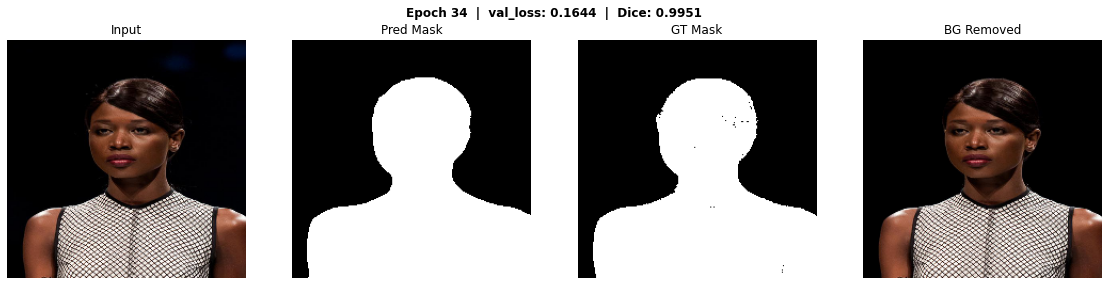

Epoch 35/100
63/63 [==============================] - 11s 168ms/step - loss: 0.0911 - accuracy: 0.9792 - dice_coefficient: 0.9816 - val_loss: 0.1866 - val_accuracy: 0.9616 - val_dice_coefficient: 0.9656
Restoring model weights from the end of the best epoch.

Epoch 00035: val_loss did not improve from 0.16216


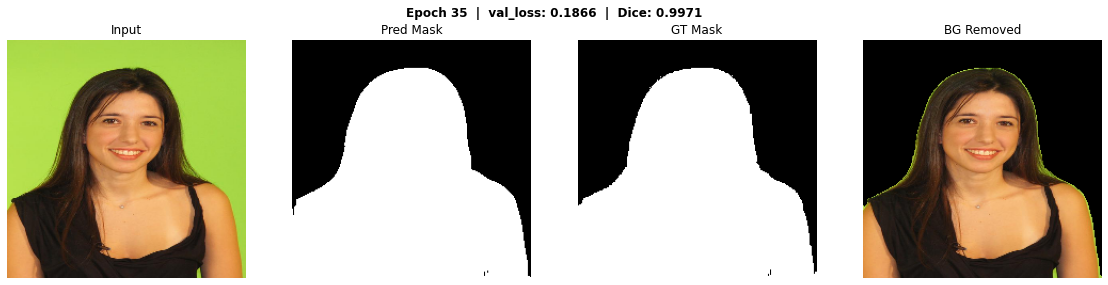

Epoch 00035: early stopping


In [12]:
callbacks = [
    EarlyStopping(patience=7, monitor='val_loss', mode='min',
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('UNet-Matting-Improved.h5', save_best_only=True, verbose=1),
    ShowProgress(),
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    verbose=1
)


## Cell 12 — Learning Curves

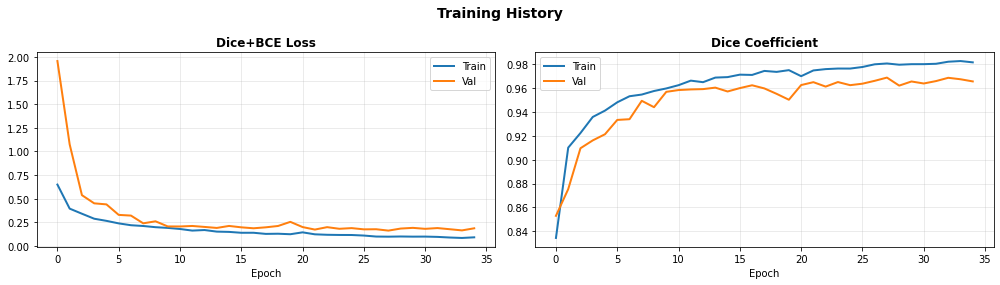

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

for ax, (tk, vk, title) in zip(axes, [
    ('loss',             'val_loss',            'Dice+BCE Loss'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient'),
]):
    ax.plot(history.history[tk], label='Train', linewidth=2)
    ax.plot(history.history[vk], label='Val',   linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Cell 13 — Evaluate with IoU (Post-Training)

`FixedMeanIoU` is added here at evaluation time only, which is safe.


In [14]:
# Recompile with IoU just for the evaluation call
model.compile(
    loss=dice_bce_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        'accuracy',
        dice_coefficient,
        FixedMeanIoU(num_classes=2, name='IoU'),  # Safe to use here
    ]
)

results = model.evaluate(X_valid, y_valid, verbose=1)
metric_names = model.metrics_names
for name, val in zip(metric_names, results):
    print(f'{name:25s}: {val:.4f}')


16/16 [==============================] - 4s 140ms/step - loss: 0.1622 - accuracy: 0.9649 - dice_coefficient: 0.9686 - IoU: 0.9314
loss                     : 0.1622
accuracy                 : 0.9649
dice_coefficient         : 0.9686
IoU                      : 0.9314


## Cell 13 — Evaluation: Background Removal & Replacement

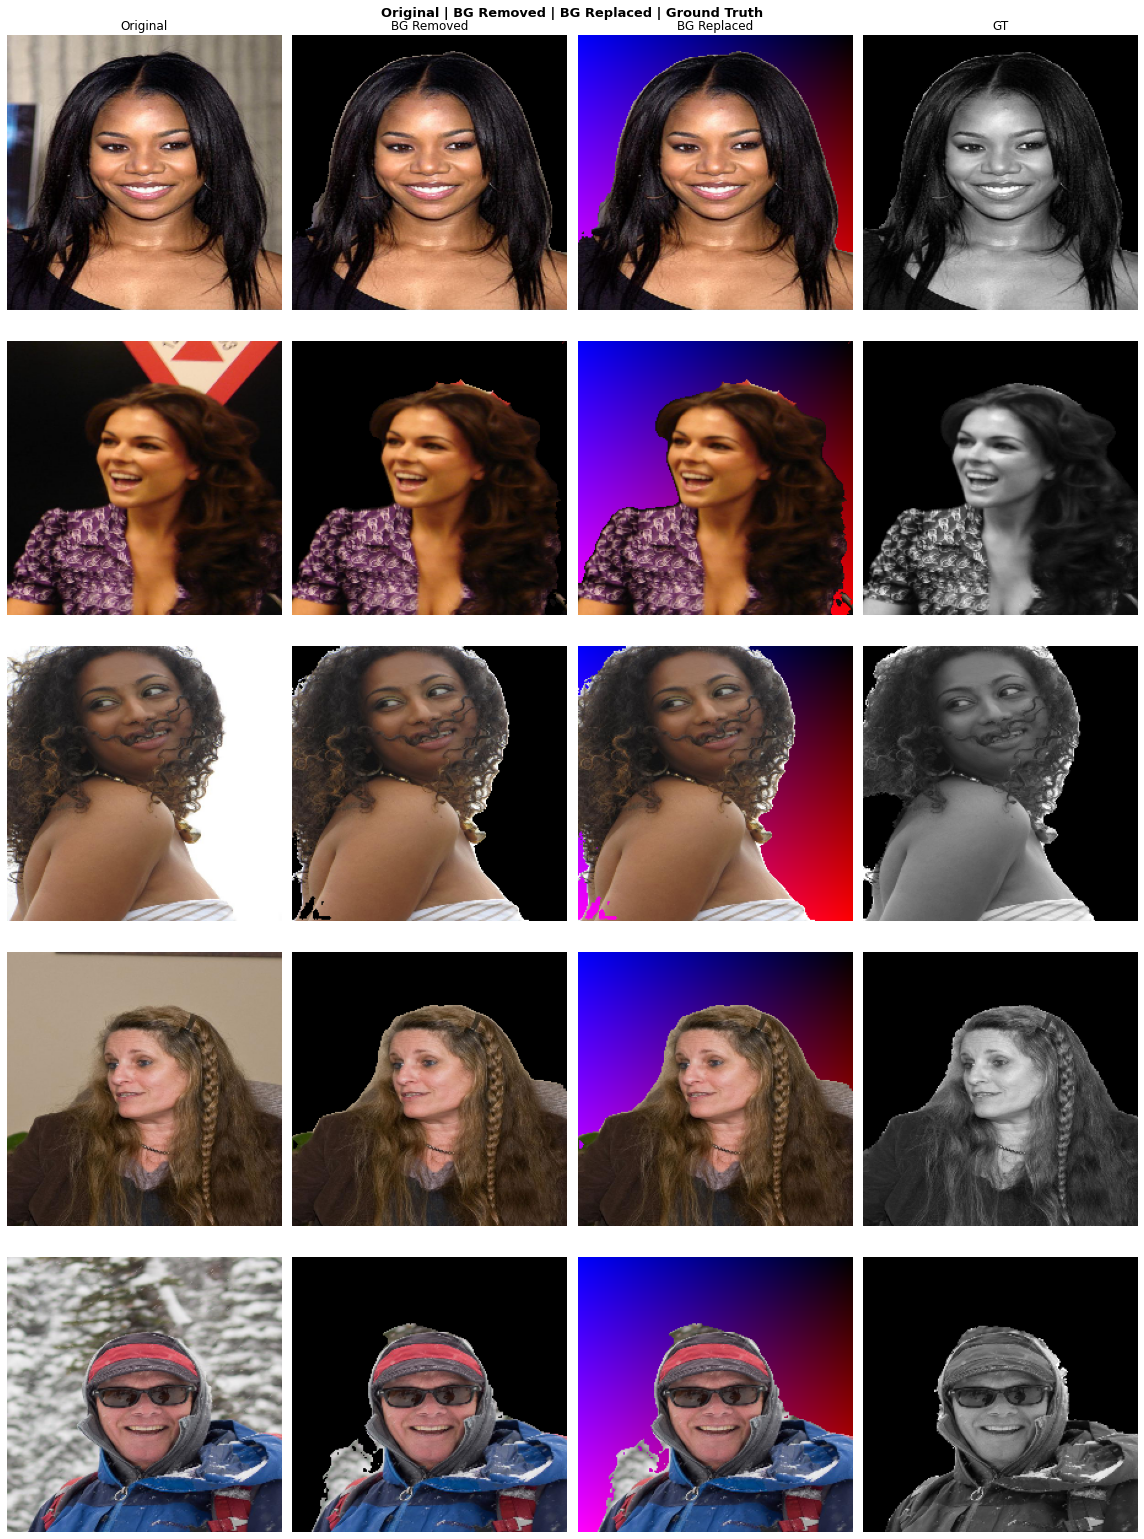

In [16]:
test_images, test_mattings, _ = data_loader(
    image_df, matting_df, BATCH_SIZE=5, IMAGE_SIZE=IMAGE_SIZE
)

# Gradient background for demo
bg_demo = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
for i in range(IMAGE_SIZE):
    bg_demo[i, :, 0] = i / IMAGE_SIZE
    bg_demo[:, i, 2] = 1.0 - i / IMAGE_SIZE

fig, axes = plt.subplots(5, 4, figsize=(16, 22))
fig.suptitle('Original | BG Removed | BG Replaced | Ground Truth',
             fontsize=13, fontweight='bold')

for k in range(5):
    img  = test_images[k]
    pred = model.predict(img[np.newaxis, ...], verbose=0)[0]
    rem  = remove_background(img, pred, threshold=0.3)
    rep  = replace_background(img, pred, bg_demo, threshold=0.3)

    axes[k][0].imshow(img);              axes[k][0].set_title('Original'   if k==0 else '')
    axes[k][1].imshow(rem[:, :, :3]);    axes[k][1].set_title('BG Removed' if k==0 else '')
    axes[k][2].imshow(rep);              axes[k][2].set_title('BG Replaced'if k==0 else '')
    axes[k][3].imshow(test_mattings[k][:,:,0], cmap='gray'); axes[k][3].set_title('GT'         if k==0 else '')
    for ax in axes[k]: ax.axis('off')

plt.tight_layout()
plt.show()

## Cell 14 — Threshold Analysis

The original notebook hardcoded threshold = 0.1. Here we sweep over thresholds and plot the Dice curve to **scientifically** find the best cutoff.

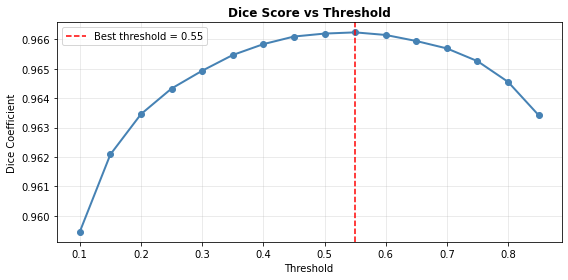

Optimal threshold: 0.55  |  Best Dice: 0.9662


In [17]:
thresholds = np.arange(0.1, 0.9, 0.05)
dice_scores = []

sample_imgs, _, sample_masks = data_loader(
    image_df, matting_df, BATCH_SIZE=50, IMAGE_SIZE=IMAGE_SIZE
)
preds = model.predict(sample_imgs, verbose=0)

for th in thresholds:
    d = dice_coefficient(
        tf.constant(sample_masks, dtype=tf.float32),
        tf.constant((preds > th).astype('float32'), dtype=tf.float32)
    ).numpy()
    dice_scores.append(d)

best_th = thresholds[np.argmax(dice_scores)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, dice_scores, 'o-', color='steelblue', linewidth=2)
plt.axvline(best_th, color='red', linestyle='--',
            label=f'Best threshold = {best_th:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
plt.title('Dice Score vs Threshold', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Optimal threshold: {best_th:.2f}  |  Best Dice: {max(dice_scores):.4f}')